# SIOC 251 Homework 3 — Part I: Monte Carlo with Isotropic Scattering

## 5.1 Model Construction

Starting from the absorption model from Homework 2, the following code adds these steps after determining path length:
- Decide whether the interaction is absorbed or scattered using the single-scatter albedo $\tilde{\omega}$.
- If scattered, determine a new direction and continue tracking the photon until it either - 
  - escapes through the TOA
  - reaches the surface
  - is absorbed.

### Scattering angle (5.1.b/c)

For isotropic scattering, $P(\cos\Theta) = 1$. The cumulative distribution function is

$$C(\cos\Theta) = \tfrac{1}{2}\int_{-1}^{\cos\Theta} 1\,dx = \tfrac{1}{2}(\cos\Theta + 1)$$

Setting $C(\cos\Theta) = \zeta$ where $\zeta \sim U(0,1)$ and solving:

$$\boxed{\cos\Theta = 2\zeta - 1}$$

Therefore $\cos\Theta$ is a random number from $[-1, 1]$. The azimuthal angle $\Phi$ is similarly drawn uniformly on $[0, 2\pi]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# random number gen
rng = np.random.default_rng(42)
#--------------
# setup scattering functions for model


def scatter_isotropic():
    """Return cos(Theta), Phi for an isotropic scattering event."""
    cos_Theta = 2.0 * rng.random() - 1.0
    Phi       = 2.0 * np.pi * rng.random()
    return cos_Theta, Phi

def rotate_to_model_coords(k, cos_Theta, Phi):
    """
    Given current propagation direction k in model coords and scattering
    angles (Theta, Phi) in the photon frame, return new direction in
    model coords.
    """
    sin_Theta = np.sqrt(1.0 - cos_Theta**2)
    kp = np.array([sin_Theta*np.cos(Phi),
                   sin_Theta*np.sin(Phi),
                   cos_Theta])

    zp = k  # photon frame z is current direction
    horiz = np.hypot(k[0], k[1])
    if horiz < 1e-10:
        xp = np.array([1.0, 0.0, 0.0])     # photon traveling vertically
    else:
        xp = np.array([-k[1], k[0], 0.0]) / horiz
    yp = np.cross(zp, xp)

    k_new = kp[0]*xp + kp[1]*yp + kp[2]*zp
    return k_new / np.linalg.norm(k_new)
    
def trace_photon(tau_star, omega, mu_0):
    """Traces a photon. Returns a path array and outcome string with - [fraction reflected (out of TOA), reached surface (no scattering),
    reached surface (with scattering), or absorbed."""
    # set initial direction after starting from solar zenith angle
    sin_theta_0 = np.sqrt(1.0 - mu_0**2)
    k   = np.array([sin_theta_0, 0.0, -mu_0])
    pos = np.array([0.0, 0.0, tau_star])
    path = [pos.copy()]
    n_scatters = 0

    # if proton scatters...
    while True:
        tau_path = -np.log(rng.random()) # set random scattering direction
        new_pos  = pos + k * tau_path #new position after travelling that direction

        if new_pos[2] >= tau_star:                       # if position higher than TOA - exiting TOA
            t = (tau_star - pos[2]) / k[2]
            path.append(pos + k * t)
            return np.array(path), 'reflected'
        if new_pos[2] <= 0.0:                            # if position lower than ground - reach surface (with or w/o scattering)
            t = -pos[2] / k[2]
            path.append(pos + k * t)
            return np.array(path), ('direct' if n_scatters == 0 else 'diffuse')

        pos = new_pos # set new position to run through while loop again
        path.append(pos.copy())

        if rng.random() >= omega:                        # if random value greater than albedo - absorbed
            return np.array(path), 'absorbed'

        cos_Theta, Phi = scatter_isotropic()
        k = rotate_to_model_coords(k, cos_Theta, Phi)
        n_scatters += 1


def monte_carlo_scatter(n_photons, tau_star, omega, mu_0):
    """Run model simulation from function above, returns outcome fractions."""
    # initialize
    counts = dict(reflected=0, direct=0, diffuse=0, absorbed=0)
    # iterate
    for _ in range(n_photons):
        _, outcome = trace_photon(tau_star, omega, mu_0)
        counts[outcome] += 1
    return {key: val / n_photons for key, val in counts.items()}

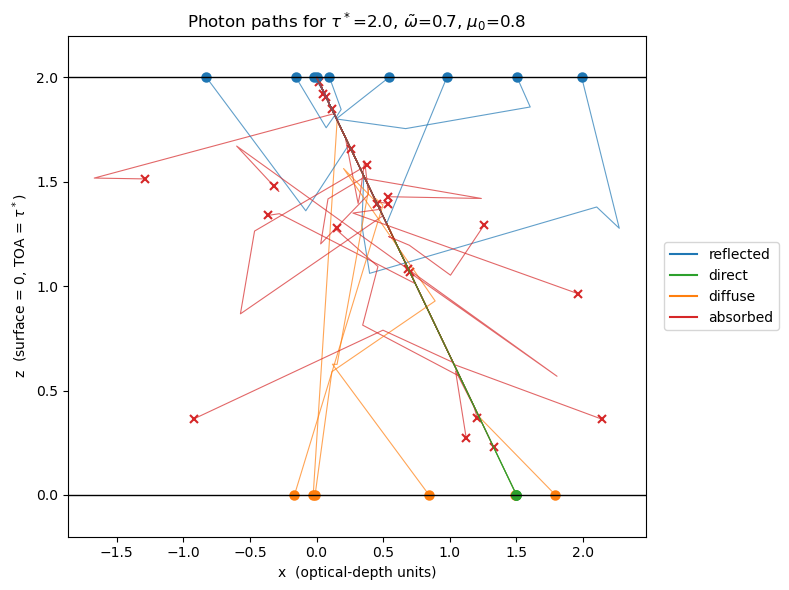


Outcome fractions (n = 20,000 photons):
  reflected : 0.225
  direct    : 0.080
  diffuse   : 0.104
  absorbed  : 0.591


In [2]:
# initials
n_plot, tau_star, omega, mu_0 = 40, 2.0, 0.7, 0.8

colors = {'reflected': 'tab:blue', 'direct':   'tab:green',
          'diffuse':   'tab:orange', 'absorbed': 'tab:red'}

# --------------------
# plot - returns photons through 4 results and cuts them off at both TOA and the surface
fig, ax = plt.subplots(figsize=(8, 6))

for _ in range(n_plot):
    path, outcome = trace_photon(tau_star, omega, mu_0)
    ax.plot(path[:, 0], path[:, 2], color=colors[outcome], lw=0.8, alpha=0.7) # plot photons through different outcome paths with set color (4 total)
    marker = 'x' if outcome == 'absorbed' else 'o'
    ax.plot(path[-1, 0], path[-1, 2], marker=marker,
            color=colors[outcome], ms=6, mew=1.5)

# draw toa and surface
ax.axhline(tau_star, color='k', lw=1)
ax.axhline(0,         color='k', lw=1)
ax.set_ylim(-0.1*tau_star, 1.1*tau_star) # cut off data at toa and surface

# label and legend
for label, c in colors.items():
    ax.plot([], [], color=c, label=label)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))

# axes and title
ax.set_xlabel('x  (optical-depth units)')
ax.set_ylabel('z  (surface = 0, TOA = $\\tau^*$)')
ax.set_title(f'Photon paths for $\\tau^*$={tau_star}, $\\tilde\\omega$={omega}, $\\mu_0$={mu_0}')

plt.tight_layout()
plt.show()

# return 4 fractions for 20000 photons (total = 1)
big = monte_carlo_scatter(20000, tau_star, omega, mu_0) 
print(f"\nOutcome fractions (n = 20,000 photons):")
for label, frac in big.items():
    print(f"  {label:10s}: {frac:.3f}")

### 5.2 Verification

Test limiting extremes - 
- $\tilde{\omega} = 0$ (only absorbtion): No scattering, so the model should reduce down to the Homework 2 model (Beer's Law). Direct transmittance must equal $e^{-\tau^*/\mu_0}$, and reflectance along with transmittance (after scattering) must be zero.
- $\tilde{\omega} = 1$ (only scattering): No atmospheric absorption, so all photons must exit through either TOA or reach surface after scattering. Absorption (outputted fraction) must be zero.

The following code tests, outputs, and verifies these limits are correct from the model - 

In [3]:
# ---------------
# Test 1: omega = 0
tau_star = 0.5
mu_0     = 0.8
res = monte_carlo_scatter(n_photons=20000, tau_star=tau_star, omega=0.0, mu_0=mu_0)
expected_direct = np.exp(-tau_star / mu_0)

print("Test 1: omega = 0 (pure absorption)")
print(f"  Direct transmittance (MC):       {res['direct']:.4f}")
print(f"  Direct transmittance (Beer):     {expected_direct:.4f}")
print(f"  Reflected (should be 0):         {res['reflected']:.4f}")
print(f"  Diffuse (should be 0):           {res['diffuse']:.4f}")
print(f"  Absorbed (should be 1-direct): {res['absorbed']:.4f}")
print("Verification test 1 passes \u2713")

# -------------
# Test 2: omega = 1
res = monte_carlo_scatter(n_photons=20000, tau_star=1.0, omega=1.0, mu_0=0.8)
total = res['reflected'] + res['direct'] + res['diffuse'] + res['absorbed']

print("\nTest 2: omega = 1 (pure scattering)")
print(f"  Reflected:                       {res['reflected']:.4f}")
print(f"  Direct + Diffuse:                {res['direct'] + res['diffuse']:.4f}")
print(f"  Absorbed (should be 0):          {res['absorbed']:.4f}")
print(f"  Sum (should be 1):               {total:.4f}")
print("Verification test 2 passes \u2713")

Test 1: omega = 0 (pure absorption)
  Direct transmittance (MC):       0.5332
  Direct transmittance (Beer):     0.5353
  Reflected (should be 0):         0.0000
  Diffuse (should be 0):           0.0000
  Absorbed (should be 1-direct): 0.4668
Verification test 1 passes ✓

Test 2: omega = 1 (pure scattering)
  Reflected:                       0.3961
  Direct + Diffuse:                0.6039
  Absorbed (should be 0):          0.0000
  Sum (should be 1):               1.0000
Verification test 2 passes ✓


### 5.3.a - Varying $\tilde\omega$ from 0 to 1

We can check the single scatter albedo at 0 to 1 at a fixed $\tau^* = 1$ and $\mu_0 = 0.8$ and track the effects of the different transmittance, absorbtion, and reflection fractions, which the following code does and plots:

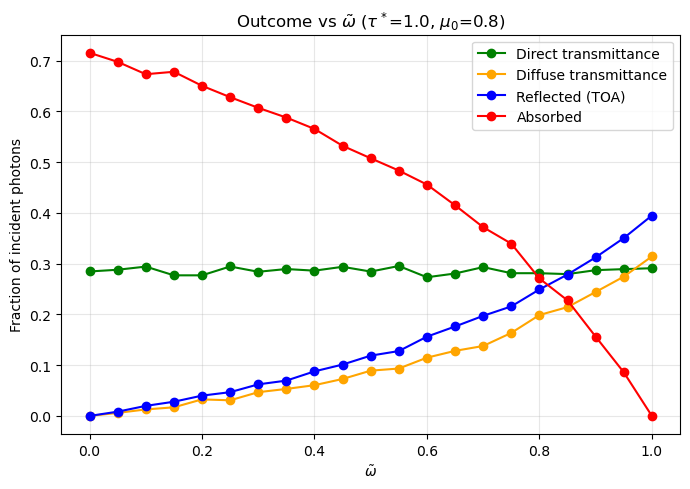

In [4]:
# initials with array of omega this time
omegas    = np.linspace(0, 1, 21)
tau_star  = 1.0
mu_0      = 0.8
n_photons = 5000

# iterate model from 0 to 1 albedo
results = {key: [] for key in ['direct', 'diffuse', 'reflected', 'absorbed']}
for w in omegas:
    r = monte_carlo_scatter(n_photons, tau_star, w, mu_0)
    for key in results: results[key].append(r[key])

# plot values of 4 fractions for different albedos 
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(omegas, results['direct'],    'g-o', label='Direct transmittance')
ax.plot(omegas, results['diffuse'],   'orange', marker='o', label='Diffuse transmittance')
ax.plot(omegas, results['reflected'], 'b-o', label='Reflected (TOA)')
ax.plot(omegas, results['absorbed'],  'r-o', label='Absorbed')
ax.set_xlabel(r'$\tilde\omega$')
ax.set_ylabel('Fraction of incident photons')
ax.set_title(fr'Outcome vs $\tilde\omega$ ($\tau^*$={tau_star}, $\mu_0$={mu_0})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.3.b — Diffuse radiation at the surface for $\tau^* \ll 1$

For this very optically thin atmosphere, photons interact much more rarely - 
- probability of interacting is $\approx \tau^*/\mu_0$
- given an interaction, probability of scattering becomes $\tilde\omega$
- after scattering, the photons evenly split to go up or down
Therfore, the diffuse transmittance at the surface is approximately

$$T_{\text{diff}} \;\approx\; \tilde\omega \cdot \frac{\tau^*}{\mu_0} \cdot \frac{1}{2} \;=\; \frac{\tilde\omega\,\tau^*}{2\mu_0}$$

Checking with an analytical solution with RTE - For isotropic scattering with a collimated source $F_0$ entering at $\mu_0$, the single-scatter source function is $J(\tau) = (\tilde\omega/4\pi)\,F_0\,e^{-\tau/\mu_0}$. The downward diffuse intensity at the surface in direction $\mu$ is

$$I_{\text{diff}}(\tau^*,\mu) = \int_0^{\tau^*} \frac{\tilde\omega F_0}{4\pi\mu}\,e^{-\tau/\mu_0}\,e^{-(\tau^*-\tau)/\mu}\,d\tau \;\xrightarrow{\tau^*\ll 1}\; \frac{\tilde\omega F_0\,\tau^*}{4\pi\mu}$$

Integrating over the downward hemisphere and dividing by the horizontal incident flux $F_0\mu_0$ gives the diffuse transmittance:

$$T_{\text{diff}} = \frac{2\pi\int_0^1 I_{\text{diff}}\,\mu\,d\mu}{F_0\,\mu_0} = \frac{\tilde\omega\,\tau^*}{2\mu_0}$$

which is the same expression. Both predict that diffuse transmittance grows linearly with $\tilde\omega$ and $\tau^*$ and decreases with $\mu_0$.

We can also check the equation derived with results from our model with a low optical depth - 

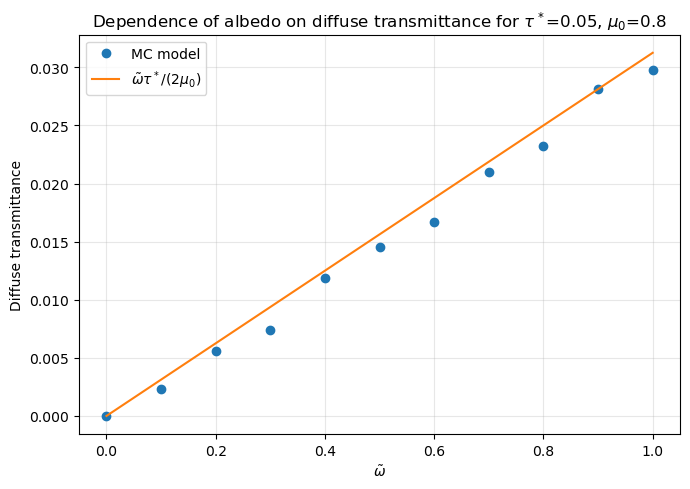

In [5]:
tau_star  = 0.05 # optically thin (<< 1)
mu_0      = 0.8
omegas    = np.linspace(0, 1, 11)
n_photons = 20000

# fraction diffused for model vs analytically 
diff_mc = [monte_carlo_scatter(n_photons, tau_star, w, mu_0)['diffuse'] for w in omegas]
diff_analytic = omegas * tau_star / (2 * mu_0)

# plot diffusion fraction with albedo (albedo array set up in previous code cell for 5.2a)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(omegas, diff_mc,'o', label='MC model')
ax.plot(omegas, diff_analytic, '-', label=r'$\tilde\omega\tau^*/(2\mu_0)$')
ax.set_xlabel(r'$\tilde\omega$')
ax.set_ylabel('Diffuse transmittance')
ax.set_title(fr'Dependence of albedo on diffuse transmittance for $\tau^*$={tau_star}, $\mu_0$={mu_0}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3.c — Why the sky is blue and sunsets are red

Since the scattering coefficient $\beta_s$ is proportional to $1/\lambda^4$, blue light ($\lambda \approx 450$ nm) scatters roughly $(650/450)^4 \approx 4.3$ times more strongly than red light ($\lambda \approx 650$ nm). We can use the model to display both colors as a different total optical depth ($\tilde\omega = 1$ for clean Rayleigh).

- Blue sky: with the sun high overhead ($\mu_0 = 1$), the reflected fraction (what we see) should therefore be much larger at the blue wavelength.
- Red sunset: with the sun near the horizon ($\mu_0 \approx 0.1$), the direct photons travel through a longer atmospheric path. Blue is scattered out far more, so the transmitted photons are dominated by the red wavelengths.

The following code affirms this with the model, confirming that the ratio between blue and red scattered photons is around 4 to 1 when the sky is overhead and greater than 4 to 1 for red photons conversely when the sun is near the horizon - 

In [6]:
tau_red, tau_blue = 0.04, 0.17     # optical depths for each color
omega = 1.0
n_photons = 20000

print("Sky results (sun overhead, mu_0 = 1.0):")
for color, tau in [('Red ', tau_red), ('Blue', tau_blue)]:
    r = monte_carlo_scatter(n_photons, tau, omega, 1.0)
    print(f"  {color}: scattered photon fraction = {r['reflected']:.4f}")

print("\nSunset results (sun near horizon, mu_0 = 0.1):")
for color, tau in [('Red ', tau_red), ('Blue', tau_blue)]:
    r = monte_carlo_scatter(n_photons, tau, omega, 0.1)
    print(f"  {color}: direct transmittance   = {r['direct']:.4f}")

Sky results (sun overhead, mu_0 = 1.0):
  Red : scattered photon fraction = 0.0213
  Blue: scattered photon fraction = 0.0766

Sunset results (sun near horizon, mu_0 = 0.1):
  Red : direct transmittance   = 0.6746
  Blue: direct transmittance   = 0.1813


### 5.3.d — question and hypothesis

Question: For a scattering atmosphere ($\tilde\omega = 1$), how does the albedo vary with optical depth?

Hypothesis: The albedo should increase with $\tau^*$ (more scattering opportunities so more backscatter as photons struggle to penetrate to the surface) and saturate toward 1 as the atmosphere becomes increasingly optically thick (for limit $\tau^* \to \infty$ no photon can make it to the surface, so all incident photons must eventually exit)

We can check this by creating an array of optical depth values this time and pltting albedo against this array from our model, focusing on reflected photons (scattering back through TOA) - 

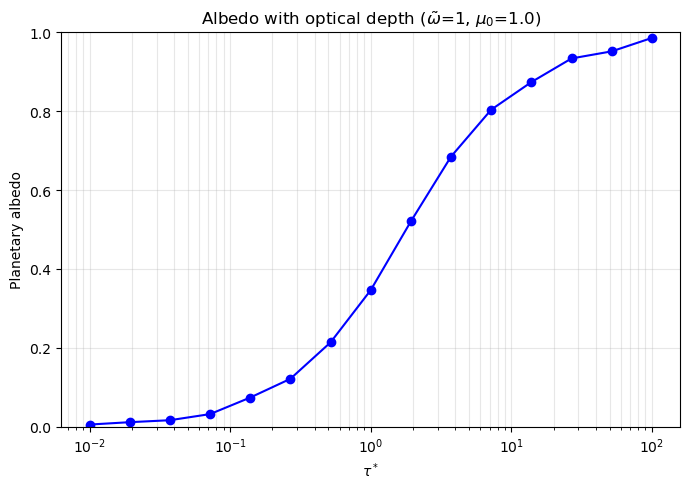

In [11]:
tau_array = np.logspace(-2, 2, 10)   
mu_0      = 1.0
omega     = 1.0
n_photons = 2000                      # was 5000

tau_array = np.logspace(-2, 2, 15)
albedo = []
for t in tau_array:
    n = 2000 if t < 5 else 500       # fewer photons where each one is slow
    albedo.append(monte_carlo_scatter(n, t, omega, mu_0)['reflected'])

fig, ax = plt.subplots(figsize=(7,5))
ax.semilogx(tau_array, albedo, 'b-o')
ax.set_xlabel(r'$\tau^*$')
ax.set_ylabel('Planetary albedo')
ax.set_title(fr'Albedo with optical depth ($\tilde\omega$=1, $\mu_0$={mu_0})')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

Result: These results confirm our hypothesis and adds a new pattern as well. The albedo rises with $\tau^*$, but forms more of an S shape, with slow increases for lower $\tau$. The slope then hits a maximum before the curve asymptotically approaches an albedo of 1 for very thick atmospheres. For $\tau^* \ll 1$ the curve follows the single-scatter (from 5.3b) prediction (linear in $\tau^*$). Around $\tau^* \sim 1$ multiple scatterings occur, and the albedo grows more slowly. For $\tau^* \gg 10$, almost no photons reach the surface (scattered back to space) and the albedo saturates. 

## AI Contribution

I used Claude and Visual Studio Code's in-house AI tools.
Use:

(1) verifying the derivation of $\cos\Theta = 2\zeta - 1$ 

(2) structuring the Monte Carlo photon-tracing code, adding that I had to introduce the coordinate rotation from the photon frame back to model coordinates 

(3) generating the photon-path visualization code (clean, easy to understand formatting) and having it clip photons at the TOA and surface boundaries

(4) assisting with deriving the single-scatter approximation and comparing that to the analytical RTE solution

(5) double checking all code for validity and written answers for clarity and correctness



- AI derivation check: Cross-referenced the single-scatter diffuse transmittance result $T_{\text{diff}} \approx \tilde\omega\tau^*/(2\mu_0)$ against an external atmospheric radiation source to confirm the factor of $1/2$ (symmetry) it stated and the $1/\mu_0$ path-length dependence was correctly derived.